# Inventory Optimization for Retail Chain

## 1) Data Introduction:

File descriptions:
- train.csv - Training data.
- test.csv - Test data.
- sample_submission.csv - a sample submission file in the correct format.

Data fields:

|Column Name|Description|
|-----------|-----------|
|date|Date of the sale data. There are no holiday effects or store closures.|
|store|Store ID|
|item|Item ID|
|sales|Number of items sold at a particular store on a particular date.|

## 2) Downloading and Importing Libraries:

In [1]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt

In [2]:
# Check libraries and Python version.
print("Python version:", sys.version)

Python version: 3.11.13 (main, Jun  3 2025, 18:38:25) [Clang 17.0.0 (clang-1700.0.13.3)]


## 3) Loading Dataset:

In [3]:
df = pd.read_csv('../data/demand-forecasting-kernels-only/train.csv')
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


## 4) Data Preprocesing and Exploratory Data Analysis:

### 4.1) Overview the dataset:

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


The dataset contains 4 columns with 913,000 non-null values and 4 features. However, the data type of the `date` column is incorrect and needs to be redefined.

In [5]:
df['date'] = pd.to_datetime(df['date'])
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 27.9 MB


The type of `date` column is correct.

**Let’s examine the values of each feature in the dataset, including the count, mean, standard deviation, minimum, 25th percentile, median (50%), 75th percentile, and maximum:**

In [7]:
df.describe()

,date,store,item,sales
count,913000,913000.000000,913000.000000,913000.000000
mean,2015-07-02 11:59:59.999999744,5.500000,25.500000,52.250287
min,2013-01-01 00:00:00,1.000000,1.000000,0.000000
25%,2014-04-02 00:00:00,3.000000,13.000000,30.000000
50%,2015-07-02 12:00:00,5.500000,25.500000,47.000000
75%,2016-10-01 00:00:00,8.000000,38.000000,70.000000
max,2017-12-31 00:00:00,10.000000,50.000000,231.000000
std,NaN,2.872283,14.430878,28.801144


The values in each column are appropriate in context.

**Let's examine the number of records by store ID:**

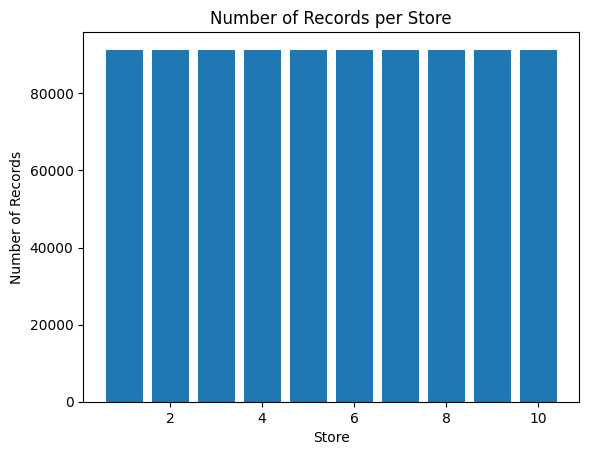

In [8]:
x = df['store'].unique()
y = df['store'].value_counts().values
plt.bar(x, y)
plt.xlabel('Store')
plt.ylabel('Number of Records')
plt.title('Number of Records per Store')
plt.show()

All stores have an equal number of records.

### 4.2) Data Preprocessing:

**Let's extract the `date` column:**

In [9]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df.head()

,date,store,item,sales,year,month,day
0,2013-01-01,1,1,13,2013,1,1
1,2013-01-02,1,1,11,2013,1,2
2,2013-01-03,1,1,14,2013,1,3
3,2013-01-04,1,1,13,2013,1,4
4,2013-01-05,1,1,10,2013,1,5


**Let's add the `day_of_week` column:**

`day_of_week`: 0 - 6 (Monday - Sunday).

`day_of_week_name`: Monday - Sunday (used as labels for charts)

In [10]:
df['day_of_week'] = df['date'].dt.dayofweek
df.head()

,date,store,item,sales,year,month,day,day_of_week
0,2013-01-01,1,1,13,2013,1,1,1
1,2013-01-02,1,1,11,2013,1,2,2
2,2013-01-03,1,1,14,2013,1,3,3
3,2013-01-04,1,1,13,2013,1,4,4
4,2013-01-05,1,1,10,2013,1,5,5


In [11]:
df['day_of_week_name'] = df['date'].dt.day_name()
df.head()

,date,store,item,sales,year,month,day,day_of_week,day_of_week_name
0,2013-01-01,1,1,13,2013,1,1,1,Tuesday
1,2013-01-02,1,1,11,2013,1,2,2,Wednesday
2,2013-01-03,1,1,14,2013,1,3,3,Thursday
3,2013-01-04,1,1,13,2013,1,4,4,Friday
4,2013-01-05,1,1,10,2013,1,5,5,Saturday


**Let's add the `is_weekend` column:**

`is_weekend`: 1 if `day_of_week` >= 5 (Saturday or Sunday), otherwise 0.

In [12]:
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >=5 else 0)
df.head()

,date,store,item,sales,year,month,day,day_of_week,day_of_week_name,is_weekend
0,2013-01-01,1,1,13,2013,1,1,1,Tuesday,0
1,2013-01-02,1,1,11,2013,1,2,2,Wednesday,0
2,2013-01-03,1,1,14,2013,1,3,3,Thursday,0
3,2013-01-04,1,1,13,2013,1,4,4,Friday,0
4,2013-01-05,1,1,10,2013,1,5,5,Saturday,1


### 4.3) Data Analysis:

#### 1) Has overall sales across the entire chain grown over time?

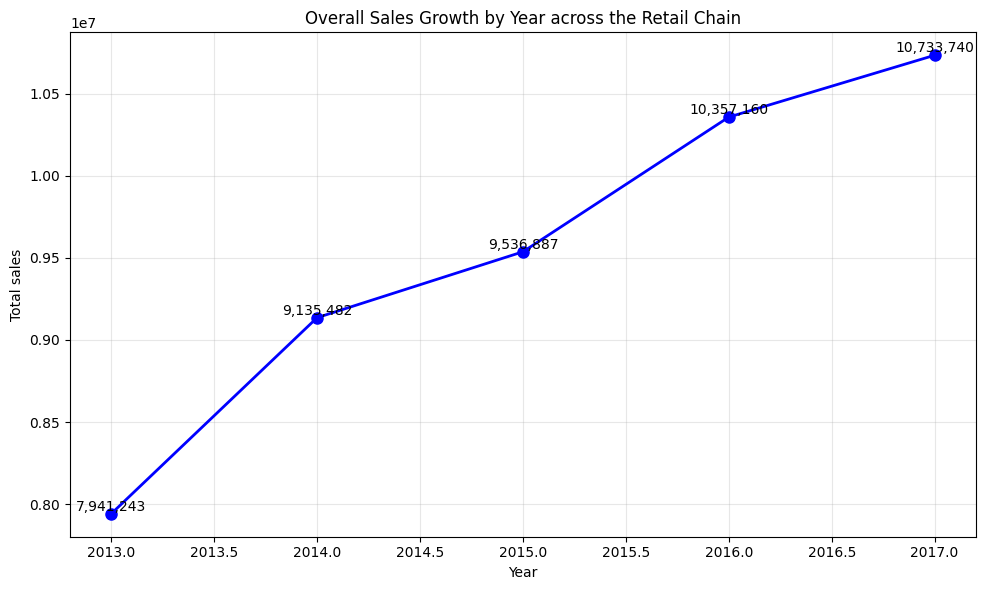

In [13]:
x = df['year'].unique()
y = df['sales'].groupby(df['year']).sum()
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', linewidth=2, marker='o', markersize=8)
for i, (xi, yi) in enumerate(zip(x, y)):
    plt.text(xi, yi, f'{yi:,.0f}', ha='center', va='bottom', fontsize=10)
plt.xlabel('Year')
plt.ylabel('Total sales')
plt.title('Overall Sales Growth by Year across the Retail Chain')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The chart shows us the sales trend across 4 years:
- In 2013, total sales across all stores reached 7,941,243 items sold.
- In 2014, sales grew significantly, with total sales increasing 1.15 times compared to 2013. This indicates that the stores were expanding very rapidly.
- In 2015, growth slowed down, but total sales across all stores still increased slightly — rising 1.04 times compared to 2014 (and 1.20 times compared to 2013).
- From 2015 to 2017, total sales increased rapidly each year.

**Overall:** From 2013 to 2017, sales increased significantly every year. This shows strong overall growth across the entire period.

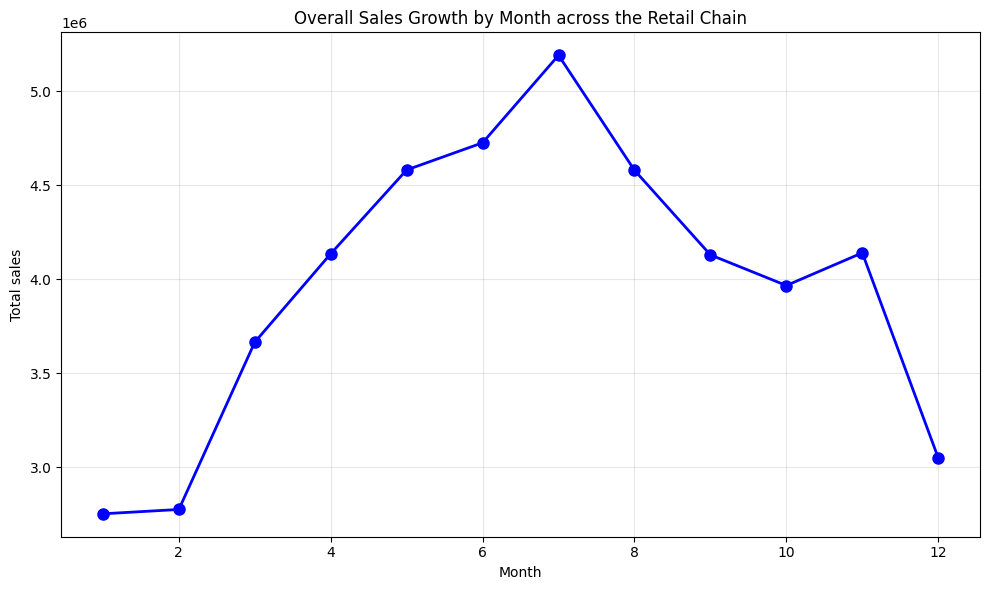

In [14]:
x = df['month'].unique()
y = df['sales'].groupby(df['month']).sum()
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', linewidth=2, marker='o', markersize=8)
plt.xlabel('Month')
plt.ylabel('Total sales')
plt.title('Overall Sales Growth by Month across the Retail Chain')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The chart shows the sales trend across 12 months:
- Total sales increased steadily from January to July, peaking in July at over 5,000,000 items sold.
- After July, sales decreased steadily over the following months. This could be due to store disruptions or reduced consumer demand. However, the decline did not last long - it ended in October, followed by an increase in November.
- In December, total sales declined significantly again.

**Overall:** Total sales showed unusual fluctuations throughout the year. Consumer demand tended to decrease in the last months of the year.

**Summary:** Although the two line charts below display different time scales, together they reveal key insights about the growth of the entire retail chain over time:
- Total sales across all stores increased steadily each year, growing from 7,941,243 items in 2013 to 10,733,740 items in 2017.
- In addition, monthly sales showed unusual fluctuations throughout the year.

#### 2) Does revenue increase on weekends?